#Grafico di funzioni di due variabili: superfici e immagini
Sia $f:{\mathbb R}^2\to{\mathbb R}$. Il grafico di $f$ è la superficie di ${\mathbb R}^3$ formata dai punti di coordinate
$$(x,y,f(x,y)), \ \ (x,y)\in{\mathbb R^2} $$

**Strumenti per la grafica 3D in Python**

Con strumenti numerici come Python è possibile approssimare il grafico di funzioni di 2 variabili su un dominio limitato, tipicamente un rettangolo

$$(x,y,f(x,y)), \ \ x\in[a,b], y\in[c,d] $$

Più precisamente, i passaggi per creare il grafico sono
1. definire una griglia di punti nel dominio rappresentazione $[a,b]\times[c,d]$
$$(x_i,y_j), i=0,...,n, j=0,...,m $$

![griglia2D.png](./Griglia2D.png)

Per creare la griglia 2D, si parte da una partizione degli intervalli $[a,b]$ e $[c,d]$, per esempio con `np.linspace` ed in seguito si calcolano con `np.meshgrid` che produce due matrici, una che contiene tutte le ascisse dei punti della griglia, l'altra le ordinate

2. Calcolare il valore della funzione nei punti della griglia
$$z_{ij} = f(x_i,y_j), \ \ i=0,...,n, j=0,...,m $$
che costituiscono una matrice

3. Utilizzare la funzione `plot_surface` per creare la grafica


**Esempio**

Consideriamo la funzione $f(x,y) = \sin(\sqrt{(x^2+y^2)})$ nel quadrato $[-5,5]\times [-5,5]$

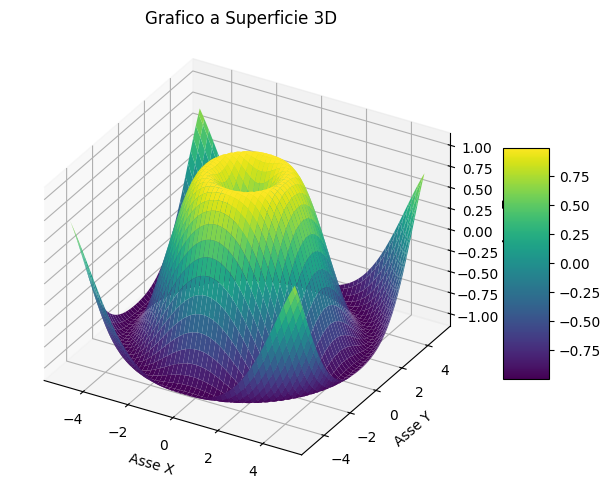

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D # Necessario per i grafici in3D

# 1. Preparazione della griglia
N = 100
#1.a partizione degli intervalli sull'asse x e sull'asse y
x = np.linspace(-5, 5, num=N)
y = np.linspace(-5, 5, num=N)
#1.b creazione delle matrici con le ascisse e le ordinate dei punti della griglia
X, Y = np.meshgrid(x, y)  # crea griglie su un intervallo in R^2 (partizione ascisse, partiziona odinate, prodotto cartesiano tra le due)
Z = np.sin(np.sqrt(X**2 + Y**2))

# 2. Creazione della figura
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d',proj_type='ortho')

# 3. Creazione del grafico
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

# 4. Aggiunta di titolo ed etichette degli assi
ax.set_title("Grafico a Superficie 3D")
ax.set_xlabel("Asse X")
ax.set_ylabel("Asse Y")
ax.set_zlabel("Asse Z")
fig.colorbar(surf, shrink=0.5, aspect=5) # Aggiunge la scala dei colori

plt.show()

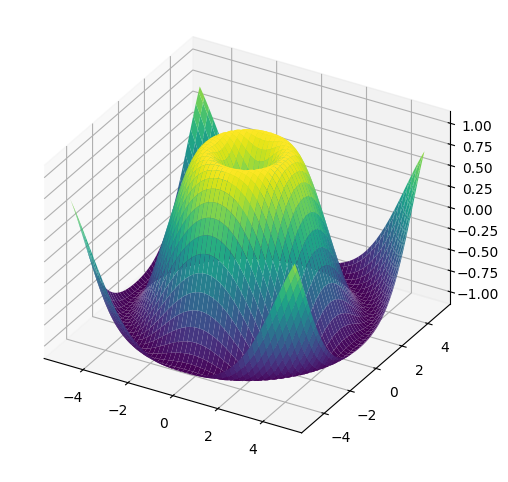

In [2]:
#Cambiamo il punto di vista sul grafico
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d',proj_type='ortho')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
# valori di default 30,-60
ax.view_init(elev=30, azim=-60)
plt.show()
plt.close()

In [3]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d',proj_type='ortho')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')


#  Funzione di aggiornamento (cambia il punto di vista, dal default (30,-60) a (90,-90))
def update(frame):
    ax.view_init(elev=30+frame, azim=-60-frame/2)
    return fig,

#  Creazione dell'animazione

ani = FuncAnimation(fig, update, frames=range(0, 61,4), interval=360)

# Chiudiamo la figura plt per evitare che Colab mostri un grafico statico duplicato
plt.close()

# Visualizzazione in formato HTML5 (fondamentale per Colab)
HTML(ani.to_html5_video())

Questo esperimento vuole sottolineare l'equivalenza tra una superficie in ${\mathbb R}^3$ e un'immagine, che di dimensioni ne ha solo 2.

La terza dimensione nell'immagine viene rappresentata mediante la scala dei colori, che associa a ciascuna gradazione un valore sull'asse $z$.

Per questo motivo le tecniche di interpolazione per funzioni di due variabili si applicano per l'elaborazione dell immagini digitali.